## Project Goal:
Generate descriptive captions for images after training on the COCO dataset. Also, Understand the limitations of the training process on such a large dataset (if any)

## Training Process and Limitations
- Training Environment: Laptop (GPU)
- Train dataset sample size - 50,000
- Number of Epochs - 5

In [1]:
import tensorflow as tf
import os
import json
import pandas as pd
import re
import numpy as np
import time
import matplotlib.pyplot as plt
import collections
import random
import requests
import json
from math import sqrt
from PIL import Image
from tqdm.auto import tqdm
from tensorflow.keras.callbacks import ModelCheckpoint

C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Path to the Coco dataset
path = 'C:/Users/moins/Downloads/archive/coco2017'

In [3]:
#Number of images to train on
sample_size=50000

In [4]:
#Load all captions from the training dataset into a dataframe
with open(f'{path}/annotations/captions_train2017.json', 'r') as f:
    data = json.load(f)
    data = data['annotations']

img_cap_pairs = []

for sample in data:
    img_name = '%012d.jpg' % sample['image_id']
    img_cap_pairs.append([img_name, sample['caption']])

captions = pd.DataFrame(img_cap_pairs, columns=['image', 'caption'])
captions['image'] = captions['image'].apply(
    lambda x: f'{path}/train2017/{x}'
)

#Samples from df to load as much as smaple_size
captions = captions.sample(sample_size)
captions = captions.reset_index(drop=True)
captions.head()

,image,caption
0,C:/Users/moins/Downloads/archive/coco2017/trai...,Two plates with a sandwich lettuce and tomato ...
1,C:/Users/moins/Downloads/archive/coco2017/trai...,A group of people sitting and standing together.
2,C:/Users/moins/Downloads/archive/coco2017/trai...,A person that is playing with a dog.
3,C:/Users/moins/Downloads/archive/coco2017/trai...,A man in a blue jacket lighting a cigarette.
4,C:/Users/moins/Downloads/archive/coco2017/trai...,A man unloading supplies from a truck near a c...


In [5]:
len(captions)

50000

In [6]:
#Prprocessing text 
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub('\s+', ' ', text)
    text = text.strip()
    text = '[start] ' + text + ' [end]'
    return text

In [7]:
captions['caption'] = captions['caption'].apply(preprocess)
captions.head()

,image,caption
0,C:/Users/moins/Downloads/archive/coco2017/trai...,[start] two plates with a sandwich lettuce and...
1,C:/Users/moins/Downloads/archive/coco2017/trai...,[start] a group of people sitting and standing...
2,C:/Users/moins/Downloads/archive/coco2017/trai...,[start] a person that is playing with a dog [end]
3,C:/Users/moins/Downloads/archive/coco2017/trai...,[start] a man in a blue jacket lighting a ciga...
4,C:/Users/moins/Downloads/archive/coco2017/trai...,[start] a man unloading supplies from a truck ...


In [9]:
MAX_LENGTH = 30
VOCABULARY_SIZE = 10300
BATCH_SIZE = 64
BUFFER_SIZE = 1000
EMBEDDING_DIM = 512
UNITS = 512

In [10]:
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCABULARY_SIZE,
    standardize=None,
    output_sequence_length=MAX_LENGTH)

#Compute the vocabulary
tokenizer.adapt(captions['caption'])

In [11]:
tokenizer.vocabulary_size()

10280

In [12]:
import pickle
#Saving the vocabulary
pickle.dump(tokenizer.get_vocabulary(), open('vocab_coco.file', 'wb'))

In [13]:
#Text to numerical representation and back
word2idx = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())

idx2word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

In [14]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(captions['image'], captions['caption']):
    img_to_cap_vector[img].append(cap)

In [15]:
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

In [16]:
slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = (img_keys[:slice_index], 
                                          img_keys[slice_index:])

In [17]:
#Key value pairs of images and their captions
#If an image appears multiple times with different captions, all those captions will be grouped together in the list associated with that image
train_imgs = []
train_captions = []
for imgt in img_name_train_keys:
    capt_len = len(img_to_cap_vector[imgt])
    train_imgs.extend([imgt] * capt_len)
    train_captions.extend(img_to_cap_vector[imgt])

In [18]:
#Key value pairs of images and their captions
#If an image appears multiple times with different captions, all those captions will be grouped together in the list associated with that image
val_imgs = []
val_captions = []
for imgv in img_name_val_keys:
    capv_len = len(img_to_cap_vector[imgv])
    val_imgs.extend([imgv] * capv_len)
    val_captions.extend(img_to_cap_vector[imgv])

In [19]:
len(train_imgs), len(train_captions), len(val_imgs), len(val_captions)

(39992, 39992, 10008, 10008)

In [20]:
#Image preprocessing with captions
def load_data(img_path, caption):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    caption = tokenizer(caption)
    return img, caption

In [21]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_imgs, train_captions))

train_dataset = train_dataset.map(
    load_data, num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_imgs, val_captions))

val_dataset = val_dataset.map(
    load_data, num_parallel_calls=tf.data.AUTOTUNE
    ).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [22]:
#Image Transformations
image_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomContrast(0.3),
    ]
)

### Inception V3
- Convolutional Neural Network part of the Inception series developed by Google
- Pre-trained on ImageNet. Great for Image Captioning with Transfer learning.
- Factorized Convolutions: Reduces computational cost by breaking down large convolutions into smaller ones.
- 
Asymmetric Convolutions: Utilizes 1xN followed by Nx1 convolutions for efficiency.- 
Efficient Grid Size Reduction: Achieves spatial reduction effectively without losing information.

In [23]:
def CNN_Encoder():
    inception_v3 = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet'
    )

    output = inception_v3.output
    output = tf.keras.layers.Reshape(
        (-1, output.shape[-1]))(output)

    cnn_model = tf.keras.models.Model(inception_v3.input, output)
    return cnn_model

### TransformerEncoderLayer
- Custom Implementation based on the Encoder architecture of the Transformer
- Embedding Dimension & Attention Heads: Initialized with a specific embedding dimension and number of attention heads.
- 
Layer Normalization Layers: Contains 2 layer normalization instances for stabilizing inputs at different points
- 
Self-Attention Mechanisms: Employs 1 MultiHeadAttention mechanism for contextual processing of inputs, leveraging specified attention head
- .
Dense Layers: Incorporates 1 dense layer with ReLU activation, placed before the self-attention step, for initial input transformati
- n.
Residual Connections: Utilizes residual connections around the self-attention mechanism, facilitating deeper layer effectiveness without gradient iss
- es.
Sequence: The architecture sequence starts with layer normalization, followed by a dense layer, then self-attention, another residual connection, and ends with a final normalization.

In [24]:
class TransformerEncoderLayer(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense = tf.keras.layers.Dense(embed_dim, activation="relu")

    def call(self, x, training):
        x = self.layer_norm_1(x)
        x = self.dense(x)

        attn_output = self.attention(
            query=x,
            value=x,
            key=x,
            attention_mask=None,
            training=training
        )

        x = self.layer_norm_2(x + attn_output)
        return x

### Embeddings Layer
- Custom Embeddings layer designed to produce embeddings for tokens and their positions within a sequence, facilitating the representation of both semantic meaning and sequential order.
- Parameters: Initialized with vocabulary size, embedding dimension, and maximum sequence length.
- 
Embedding Layers: Consists of 2 embedding layers: 1 for token embeddings (based on vocabulary size) and 1 for position embeddings (based on maximum sequence length)
- 
Token Embeddings: Converts token IDs to embeddings, capturing semantic meanin
- .
Position Embeddings: Encodes sequential position of each token, reflecting ord
- r.
Combination: Adds token and position embeddings to produce combined embeddings, integrating semantic and positional information.

In [25]:
class Embeddings(tf.keras.layers.Layer):

    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_embeddings = tf.keras.layers.Embedding(
            vocab_size, embed_dim)
        self.position_embeddings = tf.keras.layers.Embedding(
            max_len, embed_dim, input_shape=(None, max_len))
    
    def call(self, input_ids):
        length = tf.shape(input_ids)[-1]
        position_ids = tf.range(start=0, limit=length, delta=1)
        position_ids = tf.expand_dims(position_ids, axis=0)

        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)

        return token_embeddings + position_embeddings

### Transformer Decoder Layer
- Custom Implementation of the decoder architecture of a Transofrmer.
- Embedding Layer: 1 embedding layer for generating combined token and positional embeddings from input IDs.
- 
Multi-Head Attention Layers: 2 layers for attention mechanisms; attention_1 for self-attention within the decoder, attention_2 for cross-attention with the encoder output
- 
Layer Normalization: 3 layer normalization steps applied after each main operation (self-attention, cross-attention, and feed-forward network) to stabilize the outpu
- .
Feed-Forward Network (FFN): Consists of 2 dense layers; the first with ReLU activation (ffn_layer_1) and the second projecting back to embedding dimension size (ffn_layer_
- ).
Output Layer: A dense layer with softmax activation producing probabilities over the vocabulary (o
- t).
Dropout Layers: Applied after the first FFN layer (dropout_1 with 0.3 rate) and after the second layer normalization (dropout_2 with 0.5 rate) to prevent overfit
- ing.
Attention Masks: Utilizes combined masks for self-attention and padding masks for cross-attention, enhancing the model's focus and handling variable input lengths.

In [26]:
class TransformerDecoderLayer(tf.keras.layers.Layer):

    def __init__(self, embed_dim, units, num_heads):
        super().__init__()
        self.embedding = Embeddings(
            tokenizer.vocabulary_size(), embed_dim, MAX_LENGTH)

        self.attention_1 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1
        )
        self.attention_2 = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim, dropout=0.1
        )

        self.layernorm_1 = tf.keras.layers.LayerNormalization()
        self.layernorm_2 = tf.keras.layers.LayerNormalization()
        self.layernorm_3 = tf.keras.layers.LayerNormalization()

        self.ffn_layer_1 = tf.keras.layers.Dense(units, activation="relu")
        self.ffn_layer_2 = tf.keras.layers.Dense(embed_dim)

        self.out = tf.keras.layers.Dense(tokenizer.vocabulary_size(), activation="softmax")

        self.dropout_1 = tf.keras.layers.Dropout(0.3)
        self.dropout_2 = tf.keras.layers.Dropout(0.5)
    

    def call(self, input_ids, encoder_output, training, mask=None):
        embeddings = self.embedding(input_ids)

        combined_mask = None
        padding_mask = None
        
        if mask is not None:
            causal_mask = self.get_causal_attention_mask(embeddings)
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            combined_mask = tf.minimum(combined_mask, causal_mask)

        attn_output_1 = self.attention_1(
            query=embeddings,
            value=embeddings,
            key=embeddings,
            attention_mask=combined_mask,
            training=training
        )

        out_1 = self.layernorm_1(embeddings + attn_output_1)

        attn_output_2 = self.attention_2(
            query=out_1,
            value=encoder_output,
            key=encoder_output,
            attention_mask=padding_mask,
            training=training
        )

        out_2 = self.layernorm_2(out_1 + attn_output_2)

        ffn_out = self.ffn_layer_1(out_2)
        ffn_out = self.dropout_1(ffn_out, training=training)
        ffn_out = self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2)
        ffn_out = self.dropout_2(ffn_out, training=training)
        preds = self.out(ffn_out)
        return preds


    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, input_shape[1], input_shape[1]))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)],
            axis=0
        )
        return tf.tile(mask, mult)

### Image Captioning Model

- The ImageCaptioningModel class encapsulates a comprehensive approach for generating captions from images, integrating convolutional neural networks (CNNs) for image feature extraction and Transformer-based encoder-decoder architecture for text processing.
- Feature Extraction: Utilizes pre-trained CNN to extract rich image features.
- 
Encoding Image Features: Passes extracted features through an encoder for context-rich representation
- 
Decoding for Caption Generation: Utilizes decoder to sequentially generate text tokens from encoded feature
- .
Optional Image Augmentation: Applies techniques like flipping and rotation during training for data variabili
- y.
Loss and Accuracy Tracking: Monitors metrics throughout training for performance evaluat
- on.
Custom Computation: Implements specialized methods for accurate loss and accuracy calculation, handling variable-length captions and padding tokens.

In [27]:
class ImageCaptioningModel(tf.keras.Model):

    def __init__(self, cnn_model, encoder, decoder, image_aug=None):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.image_aug = image_aug
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_tracker = tf.keras.metrics.Mean(name="accuracy")

    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)


    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)
    

    def compute_loss_and_acc(self, img_embed, captions, training=True):
        encoder_output = self.encoder(img_embed, training=True)
        y_input = captions[:, :-1]
        y_true = captions[:, 1:]
        mask = (y_true != 0)
        y_pred = self.decoder(
            y_input, encoder_output, training=True, mask=mask
        )
        loss = self.calculate_loss(y_true, y_pred, mask)
        acc = self.calculate_accuracy(y_true, y_pred, mask)
        return loss, acc
    
    def train_step(self, batch):
        imgs, captions = batch

        if self.image_aug:
            imgs = self.image_aug(imgs)
        
        img_embed = self.cnn_model(imgs)

        with tf.GradientTape() as tape:
            loss, acc = self.compute_loss_and_acc(
                img_embed, captions
            )
    
        train_vars = (
            self.encoder.trainable_variables + self.decoder.trainable_variables
        )
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))
        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)

        return {"loss": self.loss_tracker.result(), "acc": self.acc_tracker.result()}
    

    def test_step(self, batch):
        imgs, captions = batch

        img_embed = self.cnn_model(imgs)

        loss, acc = self.compute_loss_and_acc(
            img_embed, captions, training=False
        )

        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)

        return {"loss": self.loss_tracker.result(), "acc": self.acc_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]

    def call(self, inputs, training=False):
        imgs, captions = inputs
    
        if self.image_aug and training:
            imgs = self.image_aug(imgs)
    
        img_embed = self.cnn_model(imgs, training=training)
        encoder_output = self.encoder(img_embed, training=training)
                             
        y_input = captions[:, :-1]
        mask = (y_input != 0) 
        y_pred = self.decoder(y_input, encoder_output, training=training, mask=mask)
    
        return y_pred


In [28]:
#Initializing the image captioning model
encoder = TransformerEncoderLayer(EMBEDDING_DIM, 1)
decoder = TransformerDecoderLayer(EMBEDDING_DIM, UNITS, 8)

cnn_model = CNN_Encoder()
caption_model = ImageCaptioningModel(
    cnn_model=cnn_model, encoder=encoder, decoder=decoder, image_aug=image_augmentation,
)

C:\Users\moins\anaconda3\envs\pymc_env\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [29]:
cross_entropy = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False, reduction="none"
)

early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=cross_entropy
)

In [30]:
history = caption_model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5259s 8s/step - acc: 0.2376 - loss: 5.0925 - val_loss: 3.7280 - val_acc: 0.3550
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5192s 8s/step - acc: 0.3654 - loss: 3.6007 - val_loss: 3.4215 - val_acc: 0.3893
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5223s 8s/step - acc: 0.3950 - loss: 3.2660 - val_loss: 3.3028 - val_acc: 0.4003
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5197s 8s/step - acc: 0.4121 - loss: 3.0796 - val_loss: 3.2398 - val_acc: 0.4094
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 5189s 8s/step - acc: 0.4237 - loss: 2.9492 - val_loss: 3.2126 - val_acc: 0.4123


### The first training was for 10 epochs where we had applied early stopping but after 7 epochs training stopped and system crashed, next time we trained it for 5 epochs.

In [98]:
import os
import tensorflow as tf

# Ensure that the 'artifacts' directory exists
if not os.path.exists('artifacts'):
    os.makedirs('artifacts')

model_name = '50000_model'  # Example model name

# Save encoder model in TensorFlow format (use .keras extension)
encoder.save(f'artifacts/encoder_model_{model_name}.keras')

# Save decoder model in TensorFlow format (use .keras extension)
decoder_model.save(f'artifacts/decoder_model_{model_name}.keras')  # Save the entire model, not just the layer

# Save encoder weights in .weights.h5 format
encoder.save_weights(f'artifacts/encoder_weights_{model_name}.weights.h5')

# Save decoder weights in .weights.h5 format
decoder_model.save_weights(f'artifacts/decoder_weights_{model_name}.weights.h5')  # Save weights for the model, not the layer

# Save encoder architecture in JSON format
with open(f'artifacts/encoder_architecture_{model_name}.json', 'w') as f:
    f.write(encoder.to_json())

# Save decoder architecture in JSON format
with open(f'artifacts/decoder_architecture_{model_name}.json', 'w') as f:
    f.write(decoder_model.to_json())  # Save model architecture, not layer

print("Models and weights saved successfully.")


Models and weights saved successfully.


In [99]:
def load_image_from_path(img_path):
    img = tf.io.read_file(img_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.keras.layers.Resizing(299, 299)(img)
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img

def generate_caption(img_path, add_noise=False):
    img = load_image_from_path(img_path)
    
    if add_noise:
        noise = tf.random.normal(img.shape)*0.1
        img = img + noise
        img = (img - tf.reduce_min(img))/(tf.reduce_max(img) - tf.reduce_min(img))
    
    img = tf.expand_dims(img, axis=0)
    img_embed = caption_model.cnn_model(img)
    img_encoded = caption_model.encoder(img_embed, training=False)

    y_inp = '[start]'
    for i in range(MAX_LENGTH-1):
        tokenized = tokenizer([y_inp])[:, :-1]
        mask = tf.cast(tokenized != 0, tf.int32)
        pred = caption_model.decoder(
            tokenized, img_encoded, training=False, mask=mask)
        
        pred_idx = np.argmax(pred[0, i, :])
        pred_idx = tf.convert_to_tensor(pred_idx)
        pred_word = idx2word(pred_idx).numpy().decode('utf-8')
        if pred_word == '[end]':
            break
        
        y_inp += ' ' + pred_word
    
    y_inp = y_inp.replace('[start] ', '')
    return y_inp

def new_generate_caption(img_path, add_noise=False):
    img = load_image_from_path(img_path)
    
    if add_noise:
        noise = tf.random.normal(img.shape)*0.1
        img = img + noise
        img = (img - tf.reduce_min(img))/(tf.reduce_max(img) - tf.reduce_min(img))
    
    img = tf.expand_dims(img, axis=0)
    img_embed = new_caption_model.cnn_model(img)
    img_encoded = new_caption_model.encoder(img_embed, training=False)

    y_inp = '[start]'
    for i in range(MAX_LENGTH-1):
        tokenized = tokenizer([y_inp])[:, :-1]
        mask = tf.cast(tokenized != 0, tf.int32)
        pred = new_caption_model.decoder(
            tokenized, img_encoded, training=False, mask=mask)
        
        pred_idx = np.argmax(pred[0, i, :])
        pred_idx = tf.convert_to_tensor(pred_idx)
        pred_word = idx2word(pred_idx).numpy().decode('utf-8')
        if pred_word == '[end]':
            break
        
        y_inp += ' ' + pred_word
    
    y_inp = y_inp.replace('[start] ', '')
    return y_inp

In [100]:
idx = random.randrange(0, len(captions))
img_path = captions.iloc[idx].image
act_caption = captions.iloc[idx].caption

In [113]:
def load_image_from_path(img_path):
    img = tf.io.read_file(img_path)  # Read the image file
    img = tf.io.decode_jpeg(img, channels=3)  # Decode JPEG image into 3 channels (RGB)
    img = tf.keras.layers.Resizing(299, 299)(img)  # Resize image to (299, 299)
    img = tf.cast(img, tf.float32)  # Convert image to tf.float32 (important for model input)
    img = tf.keras.applications.inception_v3.preprocess_input(img)  # Preprocess image for InceptionV3
    return img


In [114]:
def generate_caption(img_path, add_noise=False):
    img = load_image_from_path(img_path)  # Load and preprocess the image
    
    if add_noise:
        noise = tf.random.normal(img.shape) * 0.1  # Add random noise
        img = img + noise
        img = (img - tf.reduce_min(img)) / (tf.reduce_max(img) - tf.reduce_min(img))  # Normalize image
    
    img = tf.expand_dims(img, axis=0)  # Add batch dimension (1, 299, 299, 3)
    img_embed = caption_model.cnn_model(img)  # Get CNN feature embeddings for the image
    img_encoded = caption_model.encoder(img_embed, training=False)  # Get the encoded features

    y_inp = '[start]'
    for i in range(MAX_LENGTH-1):
        tokenized = tokenizer([y_inp])[:, :-1]  # Tokenize input text
        tokenized = tf.cast(tokenized, tf.int32)  # Ensure tokenized input is in int32 format
        mask = tf.cast(tokenized != 0, tf.int32)  # Create mask for padding tokens
        
        pred = caption_model.decoder(tokenized, img_encoded, training=False, mask=mask)  # Get predictions
        
        pred_idx = np.argmax(pred[0, i, :])  # Get index of predicted word
        pred_idx = tf.convert_to_tensor(pred_idx)  # Convert to tensor
        pred_word = idx2word(pred_idx).numpy().decode('utf-8')  # Convert index to word
        
        if pred_word == '[end]':
            break
        
        y_inp += ' ' + pred_word
    
    y_inp = y_inp.replace('[start] ', '')  # Remove start token from caption
    return y_inp


Predicted Caption: a man riding a wave on a surfboard



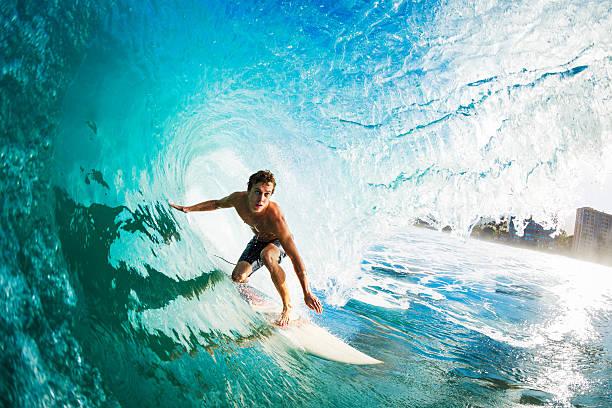

In [138]:
img_path='C:/Users/moins/Downloads/images_coco_test/surf.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

Predicted Caption: a group of people standing in a field



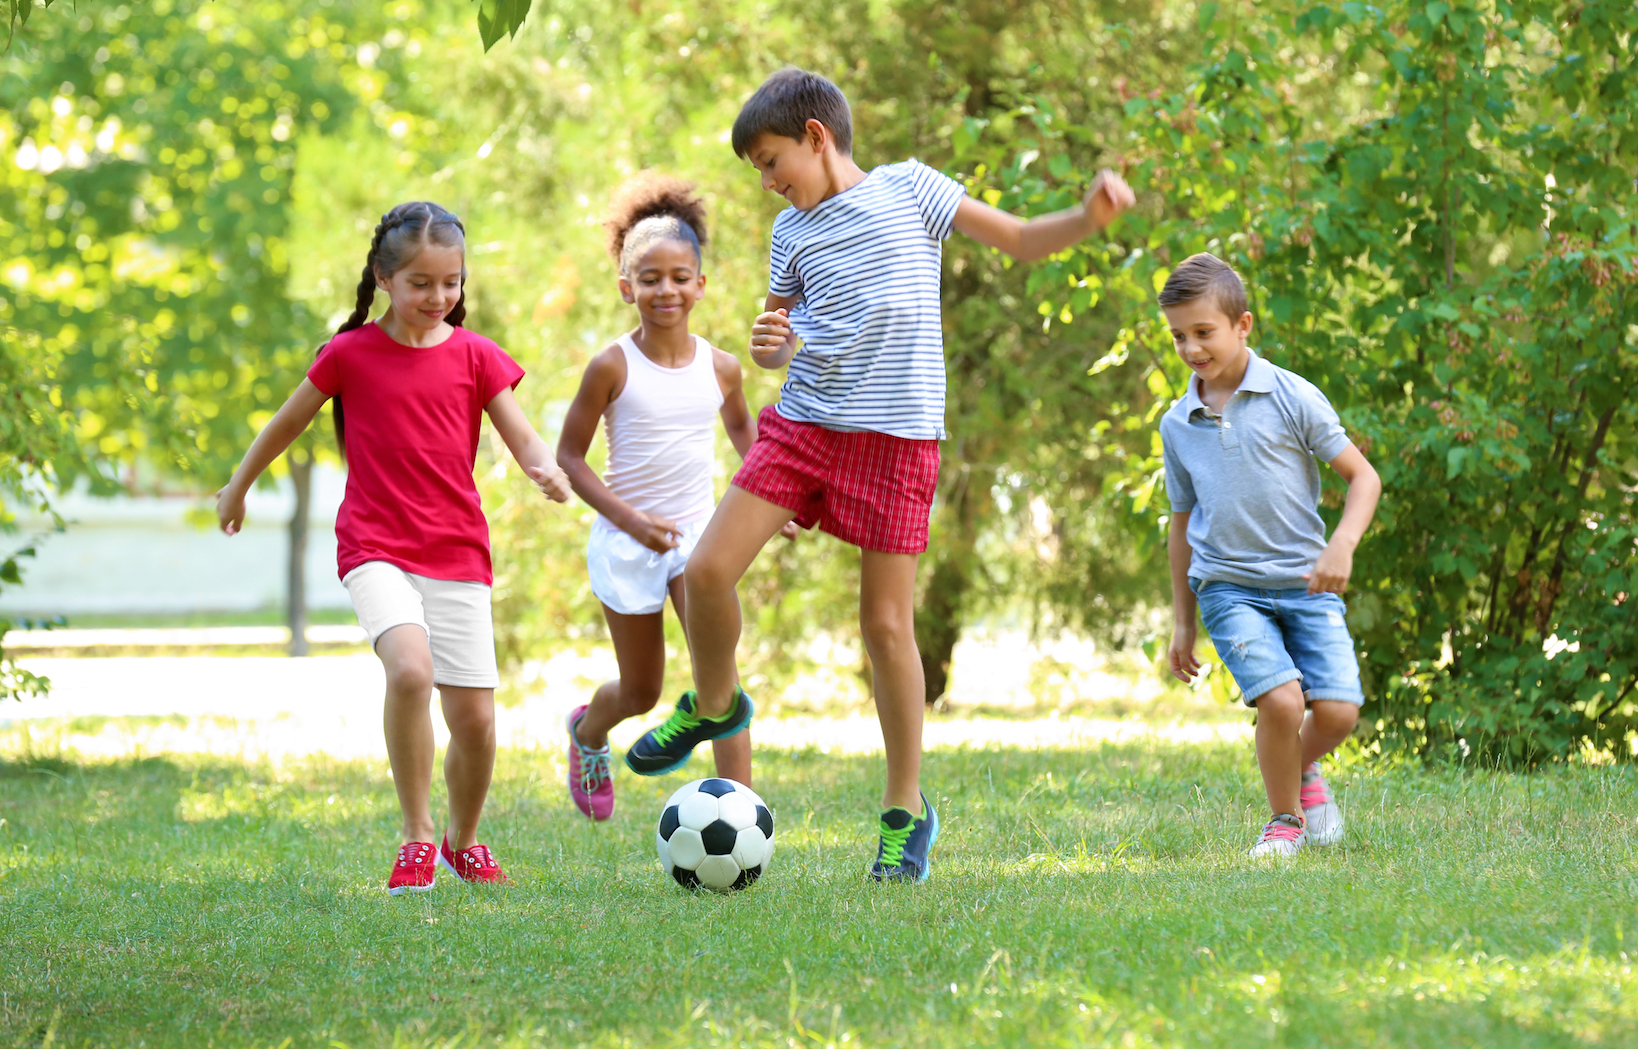

In [135]:
img_path='C:/Users/moins/Downloads/images_coco_test/kids_playing.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

Predicted Caption: a man is standing in the middle of a room



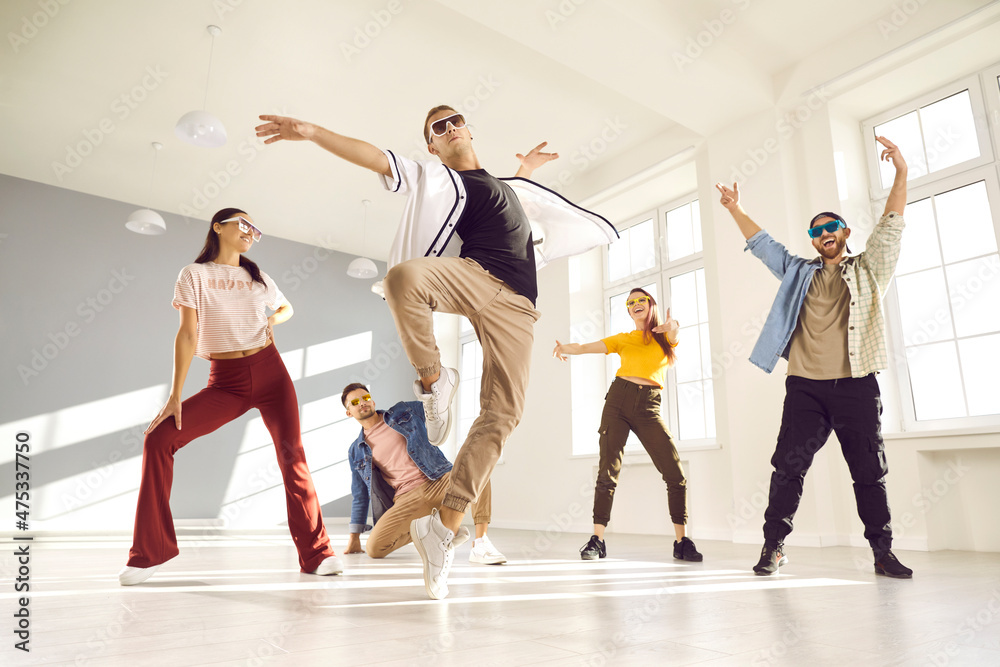

In [136]:
img_path='C:/Users/moins/Downloads/images_coco_test/people_dancing.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

Predicted Caption: a man is holding a frisbee in the grass



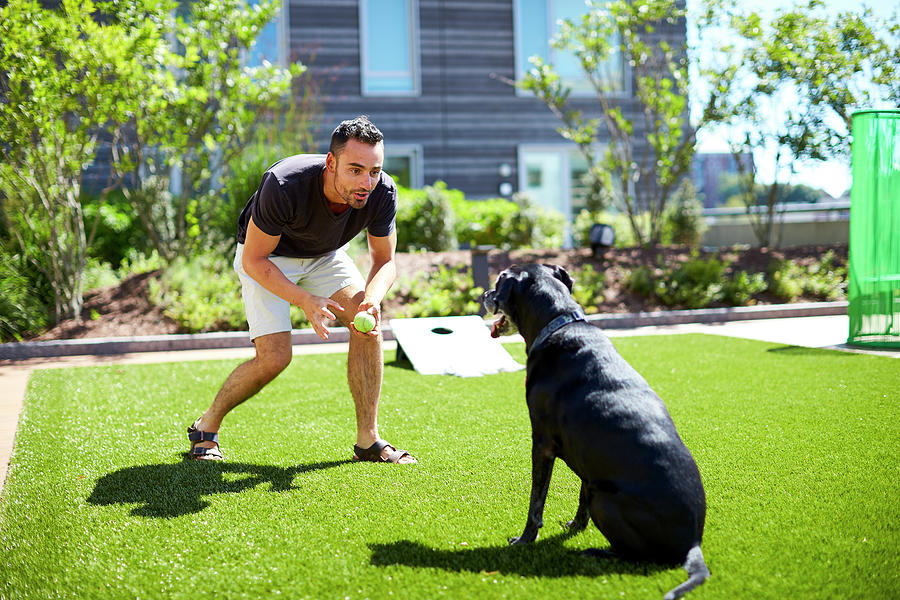

In [141]:
img_path='C:/Users/moins/Downloads/images_coco_test/dog_man.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

Predicted Caption: a cat is sitting on a chair in a room



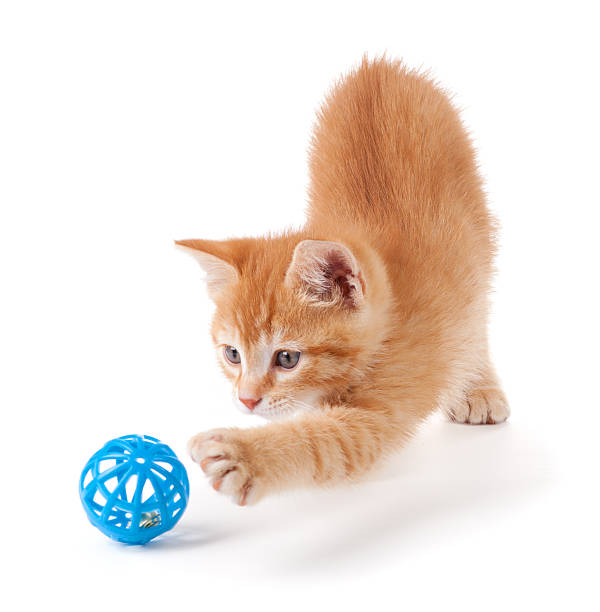

In [143]:
img_path='C:/Users/moins/Downloads/images_coco_test/cat_ball.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

Predicted Caption: a man is standing in front of a glass of wine



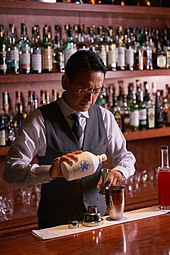

In [144]:
img_path='C:/Users/moins/Downloads/images_coco_test/bartender.jpg'
pred_caption = generate_caption(img_path)
print('Predicted Caption:', pred_caption)
print()
Image.open(img_path)

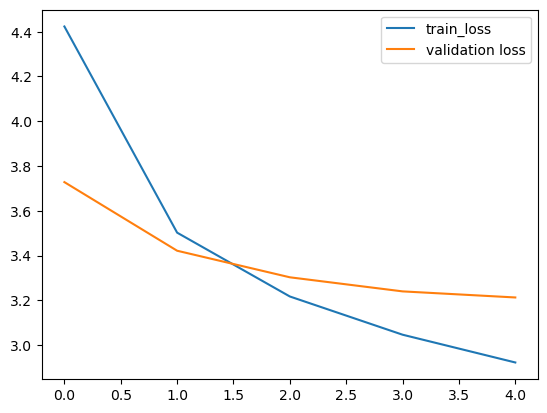

In [43]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.legend()
plt.show()